# Importing Library

## Pip install thing (just to shorten the installation log)

In [ ]:
# !pip install --user tensorflow==2.17
# !pip install --user matplotlib
# !pip install --user tensorflow-hub
# !pip install --user scikit-learn
# !pip install --user numpy==1.26.4 
# !pip install --user seaborn

## Importing Library

### Run this if you're on Jupyter Lab

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, DenseNet121
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm
from tensorflow.keras.callbacks import TensorBoard, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
# print("Hub version:", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.19.0
GPU is NOT AVAILABLE
The device is: CPU


# Extracting Data

### Loading and Unzipping Data From Drive

In [2]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [3]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
# CLASS_NAMES = [os.path.basename(l) for l in glob.glob('/content/drive/MyDrive/Colab Notebooks/train_images/train_images/*')
#                if '.' not in l]  ## if on google colab
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Load CSV file

In [4]:
# train_df = pd.read_csv('/content/drive/MyDrive/Dataset/meta_train.csv')
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


Map the path depending on the label first

In [5]:
# train_df['path'] = '/content/drive/MyDrive/Colab Notebooks/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


# Data Loading and Preprocessing

### Check Duplicates in dataset

In [ ]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images/')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Then we will remove these dulpicate ones from the dataframe
Then we need to remove it from the dataset as well.

In [ ]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\nRemoved {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

### Sorted into folder according to their variety

In [6]:
# Define output directory
output_base_dir = 'dataset/train_images_by_variety'

# Reset the output directory if it exists
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

# Recreate the base output directory
os.makedirs(output_base_dir, exist_ok=True)

# Get unique varieties
varieties = train_df['variety'].unique()
print(f"Found {len(varieties)} unique varieties: {varieties}")

# Create directories for each variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    os.makedirs(variety_dir, exist_ok=True)

# Copy files to their new locations
print("Copying images to variety folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row['path']
    dst_path = os.path.join(output_base_dir, row['variety'], row['image_id'])
    
    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by variety.")
print(f"New directory structure: {output_base_dir}/[variety]/[image_id]")

# Verify image count per variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    file_count = len([f for f in os.listdir(variety_dir) if os.path.isfile(os.path.join(variety_dir, f))])
    print(f"Variety '{variety}': {file_count} images")


Removed existing directory: dataset/train_images_by_variety
Found 10 unique varieties: ['ADT45' 'IR20' 'KarnatakaPonni' 'Onthanel' 'Ponni' 'Surya' 'Zonal'
 'AndraPonni' 'AtchayaPonni' 'RR']
Copying images to variety folders...


100%|███████████████████████████████████████████████████████████████████████████| 10407/10407 [00:11<00:00, 941.86it/s]


Done. Images have been sorted into directories by variety.
New directory structure: dataset/train_images_by_variety/[variety]/[image_id]
Variety 'ADT45': 6992 images
Variety 'IR20': 114 images
Variety 'KarnatakaPonni': 988 images
Variety 'Onthanel': 351 images
Variety 'Ponni': 657 images
Variety 'Surya': 32 images
Variety 'Zonal': 399 images
Variety 'AndraPonni': 377 images
Variety 'AtchayaPonni': 461 images
Variety 'RR': 36 images


### Map the csv depending on the variety

In [7]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_variety/' + train_df['variety'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg


In [8]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg
...,...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107607.jpg
10403,107811.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107811.jpg
10404,108547.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/108547.jpg
10405,110245.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/110245.jpg


### Data Distribution

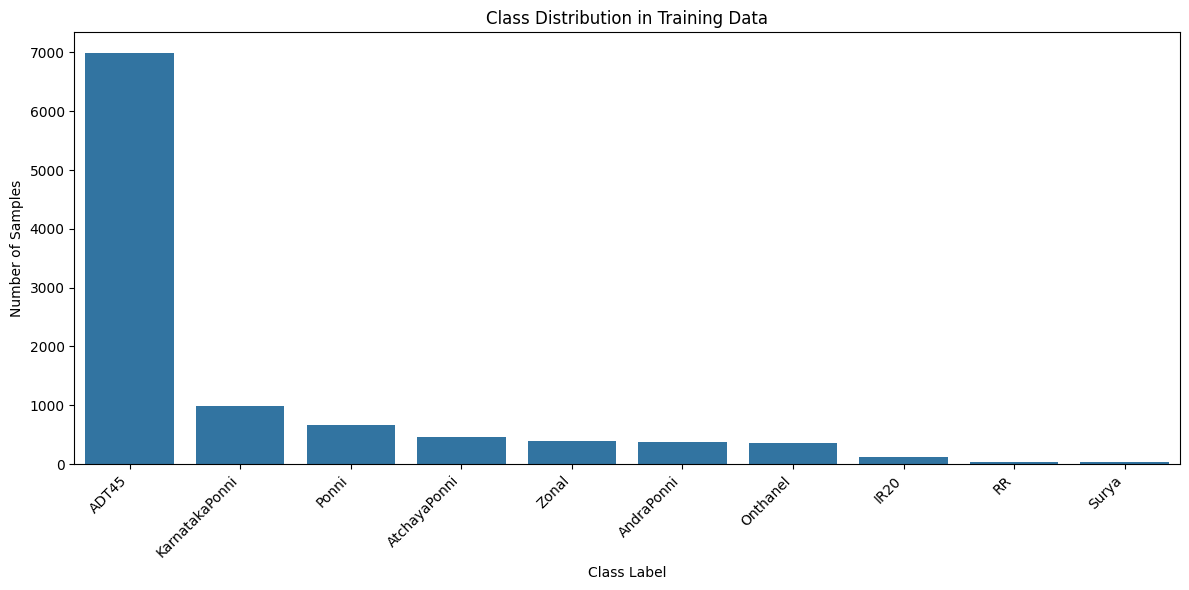

Class distribution:
ADT45: 6992 samples (67.19%)
KarnatakaPonni: 988 samples (9.49%)
Ponni: 657 samples (6.31%)
AtchayaPonni: 461 samples (4.43%)
Zonal: 399 samples (3.83%)
AndraPonni: 377 samples (3.62%)
Onthanel: 351 samples (3.37%)
IR20: 114 samples (1.10%)
RR: 36 samples (0.35%)
Surya: 32 samples (0.31%)


In [9]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['variety'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for variety, count in class_counts.items():
    print(f"{variety}: {count} samples ({count/len(train_df)*100:.2f}%)")

In [10]:
def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images('dataset/train_images_by_variety/')

Image Count Per Class:
------------------------------
ADT45                    : 6992 images
AndraPonni               : 377 images
AtchayaPonni             : 461 images
IR20                     : 114 images
KarnatakaPonni           : 988 images
Onthanel                 : 351 images
Ponni                    : 657 images
RR                       : 36 images
Surya                    : 32 images
Zonal                    : 399 images
------------------------------
Total images in dataset: 10407


## New Test Data Augmentating

In [11]:
latent_dim = 100
image_height, image_width, image_channels = 32, 32, 3

def make_generator():
    model = tf.keras.Sequential([
        layers.Dense(4*4*512, input_shape=(latent_dim,)),
        layers.Reshape((4, 4, 512)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(256, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 8x8x256

        layers.Conv2DTranspose(128, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 16x16x128

        layers.Conv2DTranspose(64, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 32x32x64

        layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')  # 💥 64x64x3
    ])
    return model

def make_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, 4, strides=2, padding='same', input_shape=(64, 64, 3)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 4, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(256, 4, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model
    
loss_fn = tf.keras.losses.BinaryCrossentropy()
gen_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

In [12]:
def train_gan(dataset, epochs=50):
    generator = make_generator()
    discriminator = make_discriminator()

    # Move these INSIDE so they reset for each new GAN
    gen_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
    disc_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

    # Define training step inside this function to access the fresh optimizers
    @tf.function
    def train_step(images):
        noise = tf.random.normal([tf.shape(images)[0], latent_dim])
        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            fake_images = generator(noise, training=True)
            real_out = discriminator(images, training=True)
            fake_out = discriminator(fake_images, training=True)

            gen_loss = tf.keras.losses.binary_crossentropy(tf.ones_like(fake_out), fake_out)
            disc_loss = (
                tf.keras.losses.binary_crossentropy(tf.ones_like(real_out), real_out) +
                tf.keras.losses.binary_crossentropy(tf.zeros_like(fake_out), fake_out)
            )

        gen_grad = gen_tape.gradient(gen_loss, generator.trainable_variables)
        disc_grad = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        gen_opt.apply_gradients(zip(gen_grad, generator.trainable_variables))
        disc_opt.apply_gradients(zip(disc_grad, discriminator.trainable_variables))

    for epoch in range(epochs):
        for batch in dataset:
            train_step(batch)

    return generator

def load_images_for_gan(class_path, target_shape=(64, 64)):
    images = []
    for fname in os.listdir(class_path):
        if not fname.lower().endswith('.jpg'):
            continue
        img = Image.open(os.path.join(class_path, fname)).resize(target_shape)
        img_array = np.array(img)
        if img_array.shape != (64, 64, 3):
            continue
        images.append(img_array)
    images = np.array(images).astype('float32')
    images = (images - 127.5) / 127.5  # Normalize to [-1, 1]
    return images

def augment_with_gan(class_name, num_to_generate, class_folder):
    print(f"[GAN] Generating {num_to_generate} images for '{class_name}'")
    images = load_images_for_gan(class_folder)

    if len(images) < 10:
        print(f"Not enough images to train GAN for '{class_name}'. Skipping.")
        return

    dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(500).batch(32)
    generator = train_gan(dataset)

    noise = tf.random.normal([num_to_generate, latent_dim])
    synthetic_imgs = generator(noise, training=False)
    synthetic_imgs = ((synthetic_imgs + 1) * 127.5).numpy().astype('uint8')

    for i, img_array in enumerate(synthetic_imgs):
        img = Image.fromarray(img_array)
        img.save(os.path.join(class_folder, f'gan_{i}.jpg'))


In [13]:
train_data_path = 'dataset/train_images_by_variety/'
underrepresented = ['Surya', 'RR', 'IR20', 'Onthanel', 'AndraPonni', 'Zonal']

# Count current images per class
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(images)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target image count per class: {average_count}")

# Apply GAN augmentation
for class_name in underrepresented:
    if class_name not in class_counts:
        continue
    current = class_counts[class_name]
    needed = average_count - current
    if needed > 0:
        class_path = os.path.join(train_data_path, class_name)
        augment_with_gan(class_name, needed, class_path)


Target image count per class: 1040
[GAN] Generating 1008 images for 'Surya'
[GAN] Generating 1004 images for 'RR'
[GAN] Generating 926 images for 'IR20'
[GAN] Generating 689 images for 'Onthanel'
[GAN] Generating 663 images for 'AndraPonni'
[GAN] Generating 641 images for 'Zonal'


## Augmentating the Data before Splitting and Loading

In [ ]:
# train_data_path = 'dataset/train_images_by_variety/'

# # Step 1: Count images per class
# class_counts = {}
# for class_name in os.listdir(train_data_path):
#     class_path = os.path.join(train_data_path, class_name)
#     if not os.path.isdir(class_path): continue
#     image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
#     class_counts[class_name] = len(image_files)

# # Step 2: Define augmentation
# augmentor = ImageDataGenerator(
#     rotation_range=25,
#     shear_range=0.25,
#     zoom_range=[0.8, 1.2],
#     width_shift_range=0.25,
#     height_shift_range=0.25,
#     brightness_range=(0.6, 1.4),
#     channel_shift_range=20.0,
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# average_count = int(np.mean(list(class_counts.values())))
# print(f"Target image count per class: {average_count}")

# # Step 3: Augment classes below the average
# for class_name, count in class_counts.items():
#     if count >= average_count:
#         print(f"Skipping '{class_name}' (already has {count} images)")
#         continue

#     class_path = os.path.join(train_data_path, class_name)
#     images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
#     current_count = count
#     augment_index = 0

#     print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
#     pbar = tqdm(total=average_count - current_count)

#     while current_count < average_count:
#         for img_name in images:
#             img_path = os.path.join(class_path, img_name)
#             img = load_img(img_path)
#             x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

#             batch = next(augmentor.flow(x, batch_size=1))
#             new_img = array_to_img(batch[0])
#             new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

#             current_count += 1
#             augment_index += 1
#             pbar.update(1)

#             if current_count >= average_count:
#                 break

#     pbar.close()


### Data Normalization and Data Generator

In [ ]:
check_total_images('dataset/train_images_by_variety/')

In [ ]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_variety/'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

With these parameters as data augmentation parameters, I split the dataset with the reatio of 0.8-0.2.

In [ ]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

In [ ]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

## Data Distribution After Augmentated

In [ ]:
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")


### Data Class Weighting

Calculate class weighting on the dataframe

In [ ]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [ ]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

## Callback functions for training monitoring and improvement

In [ ]:
# Callbacks for monitoring NaN Values
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

# Callbacks for checking loss spike
class LossSpikeStopper(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get('val_loss')
        if val_loss is not None and val_loss > 5.0 and epoch > 10:
            print(f"\n[Early Stop] Validation loss spiked to {val_loss:.4f} at epoch {epoch}.")
            self.model.stop_training = True

loss_spike_stopper = LossSpikeStopper()

# Save model after every epoch if the validation accuracy improves from previous epoch
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_cnn_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

densenet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_densenet_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

resnet50_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_resnet50_model.h5',
    monitor="val_categorical_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

# Standard learning rate reduction on plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_categorical_accuracy",
    factor=0.5,
    patience=3,
    verbose=1,
    mode="auto",
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

# Early stopping that monitors overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss instead
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# CSV logger to save training metrics to file
cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_cnn_training_history.csv',
    separator=',',
    append=True
)

densenet_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_densenet_training_history.csv',
    separator=',',
    append=True
)

resnet50_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_resnet50_training_history.csv',
    separator=',',
    append=True
)

# Tensorboard test Track metrics, images, and more with TensorBoard:
tensorboard_cb = TensorBoard(log_dir='logs', histogram_freq=1)

## Evaluation Model

In [ ]:
def evaluate_model(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
    if 'val_categorical_accuracy' in history.history:
        plt.plot(history.history['val_categorical_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

### CNN Model

In [ ]:
# For Task 2: Paddy Variety Identification with in-model augmentation
num_classes = 10
l2_reg = 1e-4  # L2 regularization strength
dropout_rate = 0.3  # You can adjust this (e.g., 0.3 to 0.5)

cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg), input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Flatten & Dense
    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Slightly higher dropout before output

    # Output
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_model.build(input_shape=(None, 224, 224, 3))
cnn_model.summary()

In [ ]:
cnn_history = model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = [
            early_stopping,
            reduce_lr,
            loss_spike_stopper,
            terminate_nan,
            cnn_checkpoint,
            cnn_csv_logger,
            tensorboard_cb,
        ]
)

In [ ]:
cnn_val_acc = evaluate_model(cnn_history)

### DenseNet Model

In [ ]:
# Load DenseNet121 for training from scratch
base_model = DenseNet121(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

num_classes = 10
l2_reg = 1e-4  # You can tune this later if needed

base_model.trainable = True

# Build the model
densenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    # First dense block
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Second dense block
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Optional: Extra layer to learn finer class separations
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Final classification layer
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

densenet_model.summary()

In [ ]:
densenet_history = model.fit(
    train_gen,
    batch_size = batch_size,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = [
            early_stopping,
            reduce_lr,
            loss_spike_stopper,
            terminate_nan,
            densenet_checkpoint,
            densenet_csv_logger,
            tensorboard_cb,
        ]
)

In [ ]:
densenet_val_acc = evaluate_model(densenet_history)

### ResNet Model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model, layers, Input, regularizers

num_classes = 10
l2_reg = 1e-4

# Base ResNet50 (from scratch)
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Input Layer
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)

# Feature Extractor
features = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.5)(features)

# Attention Mechanism
attention_weights = layers.Dense(512, activation='sigmoid', name='attention_weights')(features)
attention_output = layers.Multiply()([features, attention_weights])

# Classification Head
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(attention_output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Output Layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the Model
resnet50_model = Model(inputs=inputs, outputs=outputs)

# Compile the Model
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Show Summary
resnet50_model.summary()


In [ ]:
resnet50_history = resnet50_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=150,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32,
        callbacks=[
            terminate_nan,  # Your custom callback to catch NaN values
            resnet50_checkpoint,  # Your specific model checkpoint for ResNet50
            reduce_lr,  # Your learning rate reduction callback
            early_stopping,  # Your early stopping callback
            loss_spike_stopper,
            resnet50_csv_logger  # Your CSV logger for ResNet50
        ]
)

In [ ]:
resnet_val_acc = evaluate_model(resnet50_history)

Check best model

In [ ]:
histories = {
    "CNN": cnn_history,
    "DenseNet": densenet_history,
    "ResNet50": resnet50_history,
}

def find_best_model(histories, task_type='classification'):
    """
    histories: dict with model names as keys and History objects as values
    task_type: 'classification' or 'regression'
    """
    best_score = -float('inf') if task_type == 'classification' else float('inf')
    best_model = None

    for name, hist in histories.items():
        if task_type == 'classification':
            val_acc = max(hist.history.get('val_categorical_accuracy', [0]))
            print(f"{name}: Best Val Accuracy = {val_acc:.4f}")
            if val_acc > best_score:
                best_score = val_acc
                best_model = name
        elif task_type == 'regression':
            val_mae = min(hist.history.get('val_mae', [float('inf')]))
            print(f"{name}: Best Val MAE = {val_mae:.4f}")
            if val_mae < best_score:
                best_score = val_mae
                best_model = name

    print(f"\nBest model: {best_model} with {'accuracy' if task_type == 'classification' else 'MAE'} = {best_score:.4f}")
    return best_model

find_best_model(histories, 'classification')

In [ ]:
def evaluate_models(histories, metrics_to_check=None):
    """
    A comprehensive function to evaluate and compare multiple models based on their training histories.
    
    Parameters:
        histories: Dictionary with model names as keys and History objects as values
        metrics_to_check: List of metrics to analyze (if None, will check all available metrics)
        
    Returns:
        Dictionary with best models for different metrics
    """
    # If no specific metrics provided, collect all available metrics from histories
    if metrics_to_check is None:
        metrics_to_check = set()
        for hist in histories.values():
            for metric in hist.history.keys():
                if metric.startswith('val_'):
                    metrics_to_check.add(metric)
    
    results = {}
    summary = {}
    
    print("=" * 80)
    print(f"{'Model':<15} | {'Metric':<25} | {'Best Value':<15} | {'Epoch':<10}")
    print("=" * 80)
    
    # Process each model's history
    for model_name, history in histories.items():
        model_results = {}
        
        for metric in metrics_to_check:
            if metric in history.history:
                # Get metric values
                values = history.history[metric]
                
                # Determine if this is a metric to maximize (accuracy) or minimize (loss)
                is_maximize = not ('loss' in metric or 'error' in metric or 'mae' in metric or 'mse' in metric)
                
                # Find the best value and its epoch
                if is_maximize:
                    best_value = max(values)
                    best_epoch = values.index(best_value) + 1
                else:
                    best_value = min(values)
                    best_epoch = values.index(best_value) + 1
                
                # Store results
                model_results[metric] = {
                    'best_value': best_value,
                    'best_epoch': best_epoch,
                    'is_maximize': is_maximize
                }
                
                # Print the results
                value_format = f"{best_value:.4f}"
                print(f"{model_name:<15} | {metric:<25} | {value_format:<15} | {best_epoch:<10}")
                
                # Track the best model for each metric
                if metric not in summary:
                    summary[metric] = {
                        'best_model': model_name,
                        'best_value': best_value
                    }
                else:
                    current_best = summary[metric]['best_value']
                    if (is_maximize and best_value > current_best) or (not is_maximize and best_value < current_best):
                        summary[metric]['best_model'] = model_name
                        summary[metric]['best_value'] = best_value
        
        results[model_name] = model_results
    
    # Print overall best models
    print("\n" + "=" * 50)
    print("BEST MODEL FOR EACH METRIC:")
    print("=" * 50)
    
    for metric, data in summary.items():
        print(f"{metric:<25}: {data['best_model']} (Value: {data['best_value']:.4f})")
    
    # Visualization of training curves
    plt.figure(figsize=(15, 10))
    
    # Choose a subset of metrics to visualize (typically validation metrics)
    viz_metrics = [m for m in metrics_to_check if m.startswith('val_')]
    if not viz_metrics:
        viz_metrics = list(metrics_to_check)[:4]  # Limit to first 4 metrics if no validation metrics
    
    for i, metric in enumerate(viz_metrics[:4]):  # Limit to 4 metrics for readability
        plt.subplot(2, 2, i+1)
        
        for model_name, history in histories.items():
            if metric in history.history:
                plt.plot(history.history[metric], label=f"{model_name}")
                
                # Add corresponding training metric if available
                train_metric = metric.replace('val_', '')
                if train_metric in history.history:
                    plt.plot(history.history[train_metric], linestyle='--', 
                             alpha=0.7, label=f"{model_name} (train)")
        
        plt.title(f'{metric.replace("val_", "Validation ")}')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return summary

best_models = evaluate_models(histories)